# Бейзлайн : Catboost на социально демографических признаках и признаковых описаниях путей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [2]:
dyslexia_socdem = pd.read_excel('/home/astasiva/Eye_tracking_dyslexia/demo_groups.xlsx', sheet_name='dyslexia')
dyslexia_socdem.head()

,Group,SubjID,Sex,Grade,Age,IQ
0,dyslexia,ake05,f,3,9,35
1,dyslexia,asd17,m,4,10,34
2,dyslexia,bai24,m,1,7,28
3,dyslexia,eki26,f,1,8,35
4,dyslexia,fka11,m,2,9,32


In [3]:
norm_socdem = pd.read_excel('/home/astasiva/Eye_tracking_dyslexia/demo_groups.xlsx', sheet_name='norm')
norm_socdem['Sex'] = norm_socdem['Sex'].apply(lambda x: 'f' if x == 'fem' else 'm')
norm_socdem.head()

,Group,SubjID,Sex,Grade,Age,IQ
0,norm,10,f,4,10,23
1,norm,108,f,4,10,34
2,norm,11_norm1,f,2,9,28
3,norm,11,m,4,10,34
4,norm,12_norm1,m,2,8,32


In [4]:
risk_socdem = pd.read_excel('/home/astasiva/Eye_tracking_dyslexia/demo_groups.xlsx', sheet_name='risk')
risk_socdem.head()

,Group,SubjID,Sex,Grade,Age,IQ
0,risk,s10,m,1,7,29
1,risk,s17,f,1,7,21
2,risk,s25,f,1,7,30
3,risk,s29,m,1,6,27
4,risk,s58,f,1,8,32


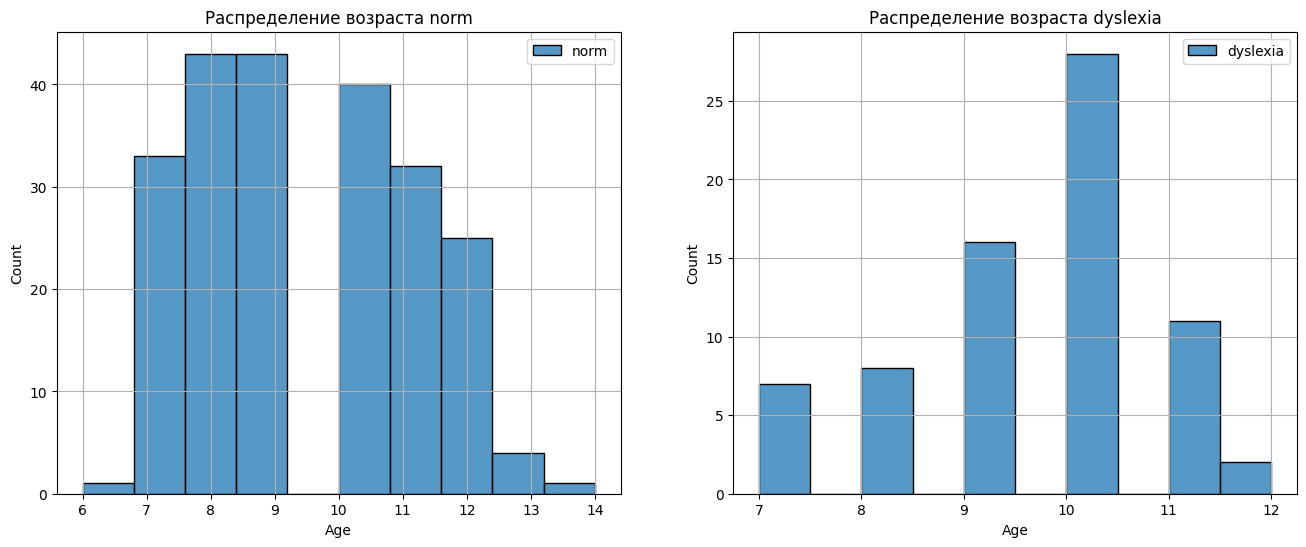

In [5]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(norm_socdem['Age'], bins=10, label = "norm")
plt.grid()
plt.legend()
plt.title("Распределение возраста norm")
plt.subplot(1, 2, 2)
sns.histplot(dyslexia_socdem['Age'], bins=10, label="dyslexia")
plt.grid()
plt.legend()
plt.title("Распределение возраста dyslexia")
plt.show();

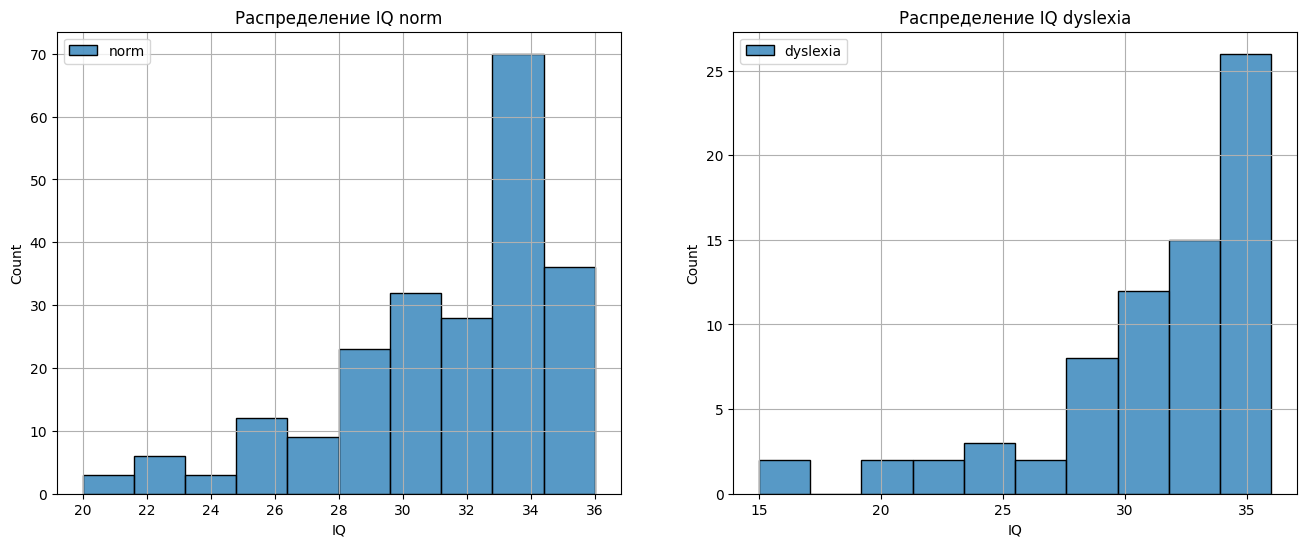

In [6]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.histplot(norm_socdem['IQ'], bins=10, label = "norm")
plt.grid()
plt.legend()
plt.title("Распределение IQ norm")
plt.subplot(1, 2, 2)
sns.histplot(dyslexia_socdem['IQ'], bins=10, label="dyslexia")
plt.grid()
plt.legend()
plt.title("Распределение IQ dyslexia")
plt.show();

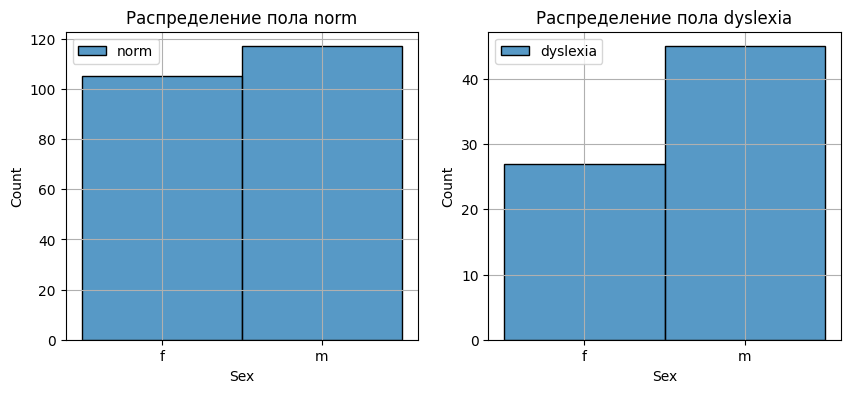

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(norm_socdem['Sex'], bins=10, label = "norm")
plt.grid()
plt.legend()
plt.title("Распределение пола norm")
plt.subplot(1, 2, 2)
sns.histplot(dyslexia_socdem['Sex'], bins=10, label="dyslexia")
plt.grid()
plt.legend()
plt.title("Распределение пола dyslexia")
plt.show();

In [8]:
fixations = pd.read_excel('/home/astasiva/Eye_tracking_dyslexia/Fixation_report_dyslexia.xlsx', sheet_name='data')
fixations.head()

,SubjectID,Sentence_ID,Word_Number,FIX_X,FIX_Y,FIX_DURATION
0,m90,26,1,169.6,503.0,613
1,m90,26,2,233.5,522.0,130
2,m90,26,1,163.8,517.1,312
3,m90,26,2,205.5,514.7,269
4,m90,26,2,240.2,517.5,413


In [9]:
sentences = pd.read_excel('/home/astasiva/Eye_tracking_dyslexia/Fixation_report_dyslexia.xlsx', sheet_name='Предложения')
sentences.head()

,number,sentence
0,4,"У них был уютный, спокойный дом, крепкая семья."
1,5,"Дорога вела в глухой лес, петляя по склонам."
2,6,"Мне было лень идти сметать снег, лежавший на м..."
3,7,"На кустах, росших по берегам реки, появились л..."
4,8,"Обещают, что в этом году лето будет жарким."


 Посмотрим на распределение точек фиксаций для детей без дислексии и с ней

In [10]:
def show_fixation(subject_id, sentence_id, color):
    plt.scatter(fixations[(fixations['SubjectID'] == subject_id) & (fixations['Sentence_ID'] == sentence_id)]['FIX_X'], 
            fixations[(fixations['SubjectID'] == subject_id) & (fixations['Sentence_ID'] == sentence_id)]['FIX_Y'], 
            alpha=0.6, color=color)

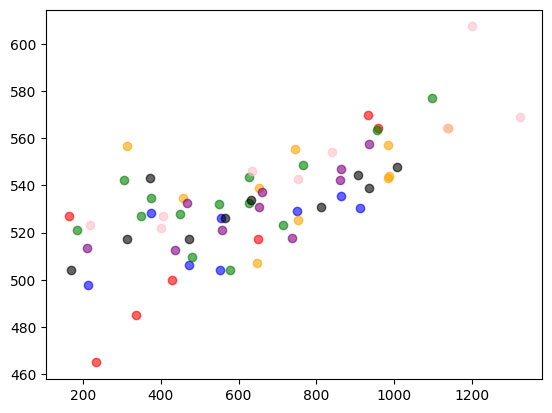

In [11]:
colors = ['red', 'blue', 'green', 'orange', 'purple', 'black', 'pink']
for i, n in enumerate([4, 5, 6, 7, 8, 9, 14]):
    show_fixation(2, n, colors[i])


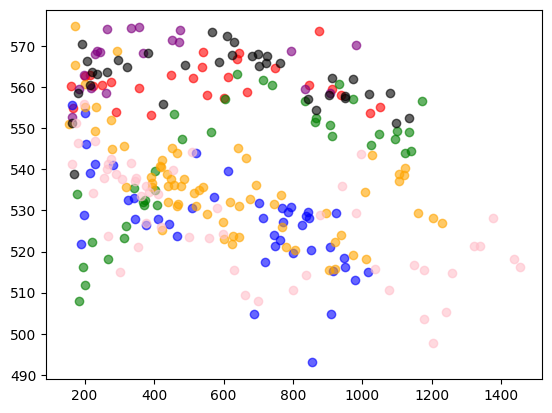

In [12]:

for i, n in enumerate([4, 5, 6, 7, 8, 9, 14]):
    show_fixation('ake05', n, colors[i])


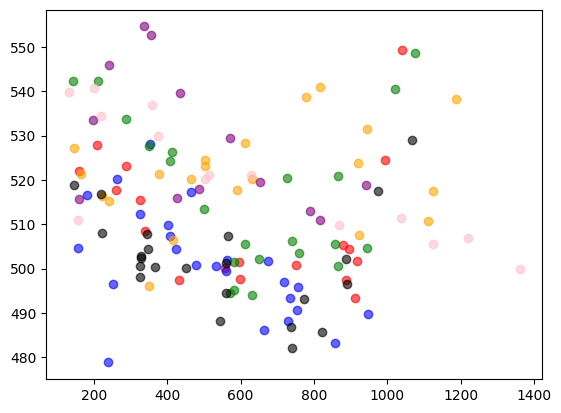

In [13]:
for i, n in enumerate([4, 5, 6, 7, 8, 9, 14]):
    show_fixation(11, n, colors[i])


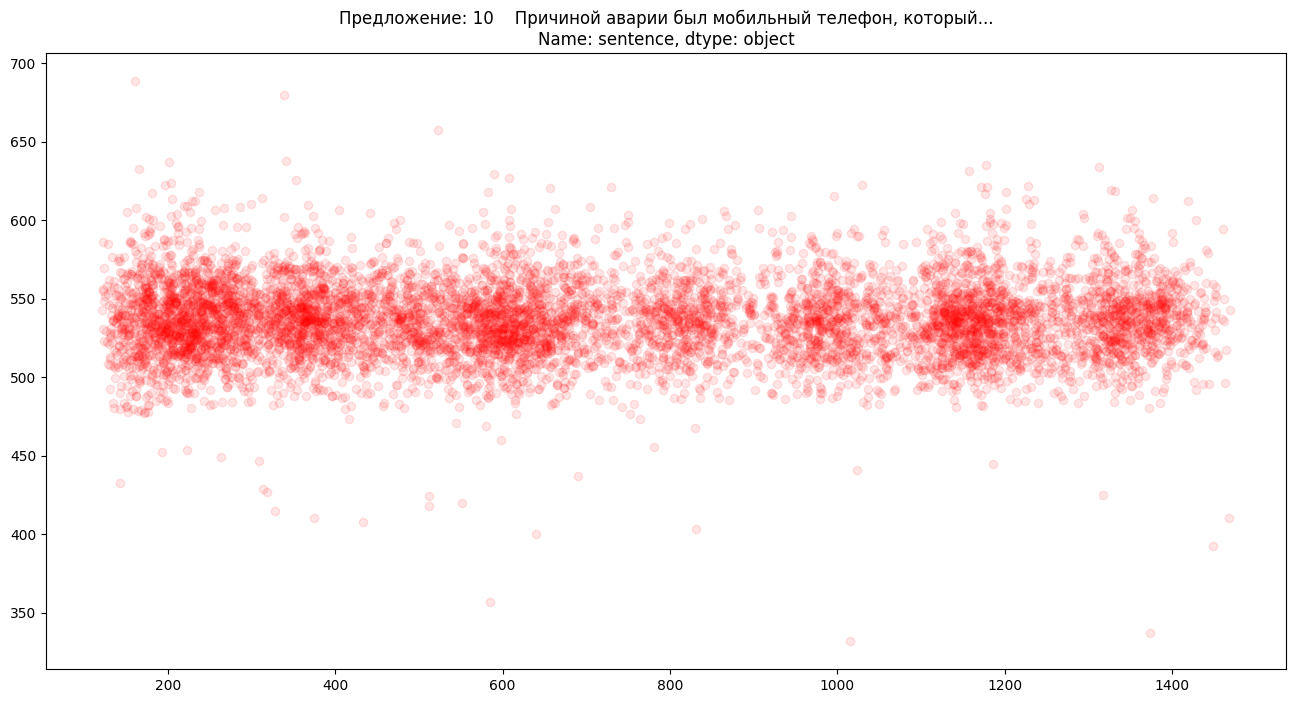

In [14]:
plt.figure(figsize=(16, 8))
sent = str(sentences[sentences['number'] == 14]['sentence'])
plt.scatter(fixations[fixations['Sentence_ID'] == 14]['FIX_X'], fixations[fixations['Sentence_ID'] == 14]['FIX_Y'], alpha=0.1, color = 'red')

plt.title(f'Предложение: { sent }');

In [15]:
def compute_sentence_level_features(fixations_df):
    """
    Вычисляет признаки на уровне каждого предложения для каждого участника
    """
    features_by_sentence = []
    
    grouped = fixations_df.groupby(['SubjectID', 'Sentence_ID'])
    
    for (subject_id, sentence_id), group in grouped:
        if len(group) < 2:  # Пропускаем слишком короткие последовательности
            continue
            
        features = {
            'SubjectID': subject_id,
            'Sentence_ID': sentence_id,
            'fix_count': len(group),
            'total_duration': group['FIX_DURATION'].sum(),
            'mean_fix_duration': group['FIX_DURATION'].mean(),
            'std_fix_duration': group['FIX_DURATION'].std()
        }
        
        features['mean_fix_x'] = group['FIX_X'].mean()
        features['mean_fix_y'] = group['FIX_Y'].mean()
        features['std_fix_x'] = group['FIX_X'].std()
        features['std_fix_y'] = group['FIX_Y'].std()
        
        dx = group['FIX_X'].diff().iloc[1:]
        dy = group['FIX_Y'].diff().iloc[1:]
        saccade_amplitudes = np.sqrt(dx**2 + dy**2)
        
        features['mean_saccade_amp'] = saccade_amplitudes.mean()
        features['max_saccade_amp'] = saccade_amplitudes.max() if len(saccade_amplitudes) > 0 else 0
        

        x_movements = group['FIX_X'].diff().iloc[1:]
        regressions = (x_movements < 0).sum()  # Движения влево = регрессии
        features['regression_count'] = regressions
        features['regression_ratio'] = regressions / max(1, len(x_movements))

        fix_order = np.arange(len(group))
        x_coords = group['FIX_X'].values
        if len(set(x_coords)) > 1:  # Проверяем, что есть вариация
            x_scan_corr = np.corrcoef(fix_order, x_coords)[0, 1]
            features['scan_regularity'] = x_scan_corr if not np.isnan(x_scan_corr) else 0
        else:
            features['scan_regularity'] = 0

        words_in_sentence = group['Word_Number'].max()
        if words_in_sentence > 0:
            features['time_per_word'] = features['total_duration'] / words_in_sentence
        
        features_by_sentence.append(features)
    
    return pd.DataFrame(features_by_sentence)

sentence_features = compute_sentence_level_features(fixations)
sentence_features.head(10)

,SubjectID,Sentence_ID,fix_count,total_duration,mean_fix_duration,std_fix_duration,mean_fix_x,mean_fix_y,std_fix_x,std_fix_y,mean_saccade_amp,max_saccade_amp,regression_count,regression_ratio,scan_regularity,time_per_word
0,2,4,7,974,139.142857,79.811086,528.828571,518.328571,324.177512,38.966255,142.261685,311.535295,1,0.166667,0.969461,139.142857
1,2,5,8,1167,145.875000,71.315071,586.412500,519.762500,241.937220,14.545587,183.110403,310.445390,2,0.285714,0.892220,145.875000
2,2,6,14,2470,176.428571,63.383709,575.785714,534.778571,251.383216,19.513592,176.185482,724.230516,4,0.307692,0.204697,274.444444
3,2,7,10,1434,143.400000,76.279020,766.490000,542.620000,260.795908,17.202248,151.372551,338.807349,2,0.222222,0.687585,179.250000
4,2,8,10,989,98.900000,52.528193,638.080000,531.220000,225.811750,15.098771,141.460013,301.041525,2,0.222222,0.863336,123.625000
5,2,9,10,1937,193.700000,71.366114,618.710000,530.350000,289.048856,14.160528,185.482027,563.713491,3,0.333333,0.625088,322.833333
6,2,10,6,1170,195.000000,30.893365,632.000000,544.300000,320.090793,7.278187,160.939380,276.439957,0,0.000000,0.990289,167.142857
7,2,11,8,1134,141.750000,73.755871,571.087500,529.000000,299.130795,34.879712,130.230760,230.842132,1,0.142857,0.989243,162.000000
8,2,12,10,1547,154.700000,88.327736,600.480000,533.420000,315.633831,21.595977,171.548467,450.852748,1,0.111111,0.858329,171.888889
9,2,13,5,1379,275.800000,253.228553,489.480000,517.580000,264.442030,8.807213,169.961509,274.931646,0,0.000000,0.986141,229.833333


In [16]:
dyslexia_socdem['dyslexia'] = 1
norm_socdem['dyslexia'] = 0
all_children = pd.concat([dyslexia_socdem, norm_socdem])
all_features = pd.merge(sentence_features, all_children, how='left', left_on='SubjectID', right_on='SubjID')
all_features.head()

,SubjectID,Sentence_ID,fix_count,total_duration,mean_fix_duration,std_fix_duration,mean_fix_x,mean_fix_y,std_fix_x,std_fix_y,...,regression_ratio,scan_regularity,time_per_word,Group,SubjID,Sex,Grade,Age,IQ,dyslexia
0,2,4,7,974,139.142857,79.811086,528.828571,518.328571,324.177512,38.966255,...,0.166667,0.969461,139.142857,norm,2,m,4.0,10.0,34.0,0.0
1,2,5,8,1167,145.875000,71.315071,586.412500,519.762500,241.937220,14.545587,...,0.285714,0.892220,145.875000,norm,2,m,4.0,10.0,34.0,0.0
2,2,6,14,2470,176.428571,63.383709,575.785714,534.778571,251.383216,19.513592,...,0.307692,0.204697,274.444444,norm,2,m,4.0,10.0,34.0,0.0
3,2,7,10,1434,143.400000,76.279020,766.490000,542.620000,260.795908,17.202248,...,0.222222,0.687585,179.250000,norm,2,m,4.0,10.0,34.0,0.0
4,2,8,10,989,98.900000,52.528193,638.080000,531.220000,225.811750,15.098771,...,0.222222,0.863336,123.625000,norm,2,m,4.0,10.0,34.0,0.0


In [17]:
child_data = []

for subject_id in all_features['SubjectID'].unique():
    child_rows = all_features[all_features['SubjectID'] == subject_id]
    
    stats = {
        'SubjectID': subject_id,
        'fix_duration_mean': child_rows['mean_fix_duration'].mean(),
        'fix_duration_std': child_rows['mean_fix_duration'].std(),
        'regression_ratio_mean': child_rows['regression_ratio'].mean(),
        'regression_ratio_std': child_rows['regression_ratio'].std(),
        'scan_regularity_mean': child_rows['scan_regularity'].mean(),
        'scan_regularity_std': child_rows['scan_regularity'].std(),
        'saccade_amp_mean': child_rows['mean_saccade_amp'].mean(),
        'time_per_word_mean': child_rows['time_per_word'].mean(),
        
        'Age': child_rows['Age'].iloc[0],
        'Sex': child_rows['Sex'].iloc[0],
        'IQ': child_rows['IQ'].iloc[0],
        'Grade': child_rows['Grade'].iloc[0],
        'dyslexia': child_rows['dyslexia'].iloc[0]
    }
    
    stats['worst_regression_ratio'] = child_rows['regression_ratio'].max() 
    stats['best_scan_regularity'] = child_rows['scan_regularity'].min()
    
    child_data.append(stats)

child_features_df = pd.DataFrame(child_data)
child_features_df.head()

,SubjectID,fix_duration_mean,fix_duration_std,regression_ratio_mean,regression_ratio_std,scan_regularity_mean,scan_regularity_std,saccade_amp_mean,time_per_word_mean,Age,Sex,IQ,Grade,dyslexia,worst_regression_ratio,best_scan_regularity
0,2,159.923208,41.430798,0.183112,0.108848,0.819756,0.251789,156.897208,201.898042,10.0,m,34.0,4.0,0.0,0.333333,0.078459
1,3,115.106455,24.380467,0.260373,0.090469,0.824605,0.253749,75.600016,374.787765,10.0,m,36.0,4.0,0.0,0.400000,0.028846
2,4,117.878023,26.323828,0.351349,0.099281,0.821143,0.229821,109.740942,284.469312,10.0,f,33.0,4.0,0.0,0.666667,0.205560
3,6,199.631303,30.960462,0.303687,0.112905,0.817368,0.204352,97.686176,511.645833,9.0,f,33.0,4.0,0.0,0.480000,0.392512
4,9,169.177901,22.376263,0.277604,0.103815,0.751223,0.283497,88.942039,490.297817,10.0,f,29.0,4.0,0.0,0.437500,0.119732


In [18]:
child_features_df = child_features_df.dropna(subset=['dyslexia'])

In [19]:
child_features_df = child_features_df.drop('SubjectID', axis=1)

In [21]:
from sklearn.model_selection import train_test_split
X = child_features_df.drop('dyslexia', axis=1)
y = child_features_df['dyslexia']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    test_size=0.2, 
                                                    shuffle=True, 
                                                    stratify=y)

In [22]:
from catboost import CatBoostClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
cb_model_1 = CatBoostClassifier(
    cat_features=cat_features,
    class_weights=[1, scale_pos_weight],
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=100
)

In [23]:
from sklearn.metrics import recall_score as recall, precision_recall_curve as PRC

cb_model_1.fit(X_train, y_train)
cb_model_predict_1 = cb_model_1.predict(X_test)

from sklearn.metrics import recall_score

recall_dyslexia = recall_score(y_test, cb_model_predict_1, pos_label=1)


balanced_recall_1 = recall_score(y_test, cb_model_predict_1, average='macro')

balanced_recall_2 = recall_score(y_test, cb_model_predict_1, average='weighted')

print(f"Recall дислексии: {recall_dyslexia:.3f}")
print(f"Balanced recall: {balanced_recall_1:.3f}")
print(f"Balanced recall: {balanced_recall_2:.3f}")

0:	total: 61.1ms	remaining: 1m 1s
100:	total: 136ms	remaining: 1.21s
200:	total: 181ms	remaining: 721ms
300:	total: 232ms	remaining: 538ms
400:	total: 288ms	remaining: 431ms
500:	total: 345ms	remaining: 343ms
600:	total: 403ms	remaining: 268ms
700:	total: 455ms	remaining: 194ms
800:	total: 507ms	remaining: 126ms
900:	total: 554ms	remaining: 60.9ms
999:	total: 601ms	remaining: 0us
Recall дислексии: 0.667
Balanced recall: 0.820
Balanced recall: 0.887


In [25]:
from sklearn.utils import resample
df_tmp = pd.concat([X, y], axis=1)
df_majority = df_tmp[df_tmp[y.name] == 0]
df_minority = df_tmp[df_tmp[y.name] == 1]
df_majority_undersampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_undersampled = pd.concat([df_majority_undersampled, df_minority])
df_undersampled['dyslexia'].value_counts()

dyslexia
0.0    72
1.0    72
Name: count, dtype: int64

In [26]:
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(
                                                                        df_undersampled.drop('dyslexia', axis=1), 
                                                                        df_undersampled['dyslexia'], 
                                                                        stratify=df_undersampled['dyslexia'],
                                                                        shuffle=True, 
                                                                        random_state=239, 
                                                                        test_size=0.2)

In [29]:
cb_model_2 = CatBoostClassifier(
    cat_features=cat_features,
    iterations=2000,
    learning_rate=0.01,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=100
)
cb_model_2.fit(X_train_balanced, y_train_balanced)
cb_model_predict_2 = cb_model_2.predict(X_test_balanced)
recall_dyslexia_balanced = recall_score(y_test_balanced, cb_model_predict_2, pos_label=1)

print(f"Recall дислексии: {recall_dyslexia_balanced:.3f}")

0:	total: 4.16ms	remaining: 8.32s
100:	total: 67.9ms	remaining: 1.28s
200:	total: 106ms	remaining: 950ms
300:	total: 151ms	remaining: 852ms
400:	total: 195ms	remaining: 778ms
500:	total: 236ms	remaining: 705ms
600:	total: 274ms	remaining: 638ms
700:	total: 312ms	remaining: 579ms
800:	total: 355ms	remaining: 531ms
900:	total: 407ms	remaining: 496ms
1000:	total: 477ms	remaining: 476ms
1100:	total: 569ms	remaining: 465ms
1200:	total: 626ms	remaining: 417ms
1300:	total: 696ms	remaining: 374ms
1400:	total: 752ms	remaining: 321ms
1500:	total: 814ms	remaining: 271ms
1600:	total: 862ms	remaining: 215ms
1700:	total: 930ms	remaining: 163ms
1800:	total: 986ms	remaining: 109ms
1900:	total: 1.04s	remaining: 54.3ms
1999:	total: 1.08s	remaining: 0us
Recall дислексии: 0.786


In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'iterations': [1000, 2000],
    'min_data_in_leaf': [1, 5, 20]
}

grid_search = GridSearchCV(
    estimator=cb_model_2,
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train_balanced, y_train_balanced)


print("Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Use best model
best_model = grid_search.best_estimator_
cb_model_predict_2 = best_model.predict(X_test_balanced)
recall_dyslexia_balanced = recall_score(y_test_balanced, cb_model_predict_2, pos_label=1)
print(f"Recall дислексии with tuned model: {recall_dyslexia_balanced:.3f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
0:	total: 48.4ms	remaining: 48.3s
0:	total: 47.8ms	remaining: 47.8s
0:	total: 49.6ms	remaining: 49.6s
0:	total: 51.7ms	remaining: 51.6s
0:	total: 48.9ms	remaining: 48.8s
0:	total: 49.4ms	remaining: 49.4s
0:	total: 71ms	remaining: 1m 10s
0:	total: 53ms	remaining: 53s
0:	total: 74.5ms	remaining: 1m 14s
0:	total: 54.9ms	remaining: 54.9s
0:	total: 50.3ms	remaining: 50.3s
0:	total: 49.3ms	remaining: 49.3s
0:	total: 70.5ms	remaining: 1m 10s
0:	total: 49.2ms	remaining: 49.1s
0:	total: 66ms	remaining: 1m 5s
0:	total: 214ms	remaining: 3m 33s
100:	total: 702ms	remaining: 6.25s
100:	total: 816ms	remaining: 7.26s
100:	total: 1.26s	remaining: 11.2s
100:	total: 1.47s	remaining: 13s
100:	total: 1.56s	remaining: 13.9s
100:	total: 1.6s	remaining: 14.2s
100:	total: 1.53s	remaining: 13.6s
200:	total: 1.7s	remaining: 6.77s
100:	total: 1.68s	remaining: 15s
100:	total: 1.65s	remaining: 14.7s
100:	total: 1.77s	remaining: 15.7s
100:	total: 1.92s	re

In [32]:
from sklearn.metrics import precision_score, accuracy_score, f1_score
print("precision: ", precision_score(y_test_balanced, cb_model_predict_2))
print("accuracy: ", accuracy_score(y_test_balanced, cb_model_predict_2))
print("f1: ", f1_score(y_test_balanced, cb_model_predict_2))

precision:  0.75
accuracy:  0.7931034482758621
f1:  0.8


In [21]:
import networkx as nx
import numpy as np

def create_graph_for_subject_and_sentence(fixations_df):
    subject_graphs = {}

    for subject_id, group in fixations_df.groupby('SubjectID'):
        subject_graph = {}

        for sentence_id, sentence_group in group.groupby('Sentence_ID'):
            G = nx.Graph()
            
            # Reset index to ensure we have sequential indices
            sentence_group = sentence_group.reset_index(drop=True)
            
            # Add nodes
            for idx, row in sentence_group.iterrows():
                G.add_node(idx, feature=row[['FIX_X', 'FIX_Y', 'FIX_DURATION']].values)

            # Add edges between consecutive fixations
            for i in range(len(sentence_group) - 1):
                node1 = i
                node2 = i + 1

                # Use iloc for positional indexing
                time_diff = sentence_group.iloc[node2]['FIX_DURATION'] - sentence_group.iloc[node1]['FIX_DURATION']
                
                distance = np.sqrt(
                    (sentence_group.iloc[node2]['FIX_X'] - sentence_group.iloc[node1]['FIX_X'])**2 +
                    (sentence_group.iloc[node2]['FIX_Y'] - sentence_group.iloc[node1]['FIX_Y'])**2
                )
                
                is_regression = sentence_group.iloc[node2]['FIX_X'] < sentence_group.iloc[node1]['FIX_X']
                
                G.add_edge(node1, node2, weight=distance, time_diff=time_diff, is_regression=is_regression)

            subject_graph[sentence_id] = G

        subject_graphs[subject_id] = subject_graph

    return subject_graphs

subject_graphs = create_graph_for_subject_and_sentence(fixations)

subject_id = 'm90'
sentence_id = 26 

if subject_id in subject_graphs and sentence_id in subject_graphs[subject_id]:
    sentence_graph = subject_graphs[subject_id][sentence_id]

    print(f"Граф для предложения {sentence_id} ребенка {subject_id}:")
    print(f"Количество вершин: {sentence_graph.number_of_nodes()}")
    print(f"Количество рёбер: {sentence_graph.number_of_edges()}")
else:
    print(f"Граф для subject_id={subject_id}, sentence_id={sentence_id} не найден")

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from dgl.nn import GraphConv
import dgl

# Модель GCN для классификации
class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.conv1 = GraphConv(in_feats, hidden_feats)
        self.conv2 = GraphConv(hidden_feats, out_feats)

    def forward(self, g, features):
        h = self.conv1(g, features)
        h = torch.relu(h)
        h = self.conv2(g, h)
        return h

# Пример подготовки данных (граф + признаки вершин)
g = dgl.from_networkx(subject_graphs['m90'][26])  # Пример для ребенка m90, предложение 26
features = torch.tensor(fixations[['FIX_X', 'FIX_Y', 'FIX_DURATION']].values, dtype=torch.float32)
labels = torch.tensor(fixations['dyslexia'].values, dtype=torch.long)

model = GCN(in_feats=3, hidden_feats=16, out_feats=2)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# Обучение
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(g, features)
    loss = loss_fn(output, labels)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}: Loss {loss.item()}')

# Прогнозирование
model.eval()
with torch.no_grad():
    output = model(g, features)
    predicted = torch.argmax(output, dim=1)
